In [37]:
import pandas as pd
from pathlib import Path

# Choose alpha here
alpha_value = 0.3
alpha_str = f"{alpha_value:.3f}"   # will format like 0.300

workspace_root = Path.cwd().parents[3]
results_dir = workspace_root / "policies" / "sjovik_sund" / "simulation_results"

# build filename using alpha
trip_requests_file = (
    results_dir
    / "current results"
    / f"sjovik_sund_alphas_0812252309_TD_seed_1_alpha01-05_fullweek_{alpha_str}_results_trip_requests_seed_1.csv"
)

bike_criticality = pd.read_csv(r"C:\Users\Minamsj\FOMOsim\policies\sjovik_sund\simulation_results\Rough_result_000125\sjovik_sund_alphas_1112251951_TD_000125_seed_1_alpha01-05_fullweek_0.200_results_trip_requests_seed_1.csv")

print("Loaded:", trip_requests_file)


Loaded: c:\Users\Minamsj\FOMOsim\policies\sjovik_sund\simulation_results\current results\sjovik_sund_alphas_0812252309_TD_seed_1_alpha01-05_fullweek_0.300_results_trip_requests_seed_1.csv


In [38]:
#table of how many times each bike is used
bike_usage = bike_criticality['Bike ID'].value_counts()
print(bike_usage)

Bike ID
B104    31
B560    31
B603    30
B482    30
B256    29
        ..
B161     2
B585     2
B410     2
B766     1
B322     1
Name: count, Length: 764, dtype: int64


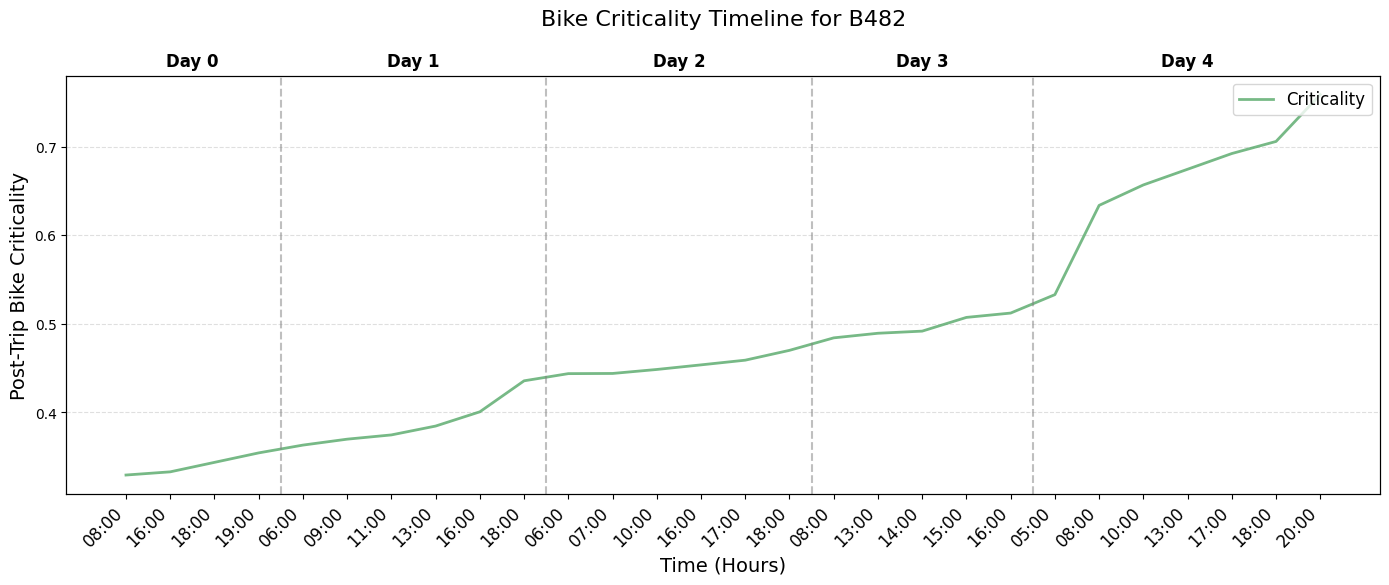

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1. SETUP DATA (Same as before)
bike_id = "B482"
df_bike = bike_criticality[bike_criticality["Bike ID"] == bike_id]

if df_bike.empty:
    raise ValueError(f"No rows found for bike {bike_id}")

# Aggregate by (Day, Hour) -> mean Bike Criticality
agg = (
    df_bike.groupby(["Day", "Hour"])["Post-Trip Bike Criticality"]
    .mean()
    .reset_index()
)

# 2. PREPARE FOR PLOTTING
# Sort by Day then Hour and RESET INDEX. 
# The index (0, 1, 2...) becomes our X-axis.
agg_sorted = agg.sort_values(["Day", "Hour"]).reset_index(drop=True)

# Create a pretty string label for the bottom axis
agg_sorted["hour_label"] = agg_sorted["Hour"].apply(lambda h: f"{int(h):02d}:00")

# --- A. Identify Day Boundaries (Vertical Lines) ---
# Find indices where 'Day' changes compared to the previous row
day_change_idx = agg_sorted.index[agg_sorted["Day"].ne(agg_sorted["Day"].shift())].tolist()
# Skip index 0 (the start of the plot)
boundary_positions = day_change_idx[1:]

# --- B. Calculate Day Centers (Top Axis Labels) ---
day_centers = []
day_labels = []

for day_val in agg_sorted["Day"].unique():
    # Find all indices belonging to this specific day
    idxs = agg_sorted.index[agg_sorted["Day"] == day_val]
    if len(idxs) > 0:
        # The visual center is the average of the first and last index of that day
        center = (idxs[0] + idxs[-1]) / 2
        day_centers.append(center)
        day_labels.append(f"Day {int(day_val)}")

# 3. PLOT
fig, ax = plt.subplots(figsize=(14, 6))

x = agg_sorted.index
y = agg_sorted["Post-Trip Bike Criticality"]

# Main Line
ax.plot(
    x, y,
    linestyle="-",       # Added markers to make points distinct
    color='#55a868',   # Nice olive green
    linewidth=2,
    alpha=0.8,
    label="Criticality"
)

# Vertical Day Separators
for pos in boundary_positions:
    # Draw line halfway between the last hour of Day A and first hour of Day B
    # (pos is the index of the first hour of Day B, so pos - 0.5 puts it between them)
    ax.axvline(x=pos - 0.5, color="gray", linestyle="--", linewidth=1.5, alpha=0.5)

# 4. AXIS FORMATTING

# --- Bottom Axis (Hours) ---
ax.set_xlabel("Time (Hours)", fontsize=14)
ax.set_ylabel("Post-Trip Bike Criticality", fontsize=14)

# Pick a step size to avoid crowding labels (e.g., aim for ~20 labels max)
step = max(1, len(agg_sorted) // 20)
ax.set_xticks(list(x)[::step])
ax.set_xticklabels(
    agg_sorted["hour_label"].iloc[::step], 
    rotation=45, 
    ha="right", 
    fontsize=12
)

# --- Top Axis (Days) ---
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())  # Crucial: Sync x-limits with bottom axis

ax2.set_xticks(day_centers)
ax2.set_xticklabels(day_labels, fontsize=12, fontweight='bold')

# Style the top axis to look cleaner (remove ticks, keep labels)
ax2.xaxis.set_ticks_position("top")
ax2.tick_params(axis='x', length=0) 

# Grid and Final Touches
ax.grid(True, which='major', axis='y', linestyle='--', alpha=0.4)
ax.legend(loc="upper right", fontsize=12)
plt.title(f"Bike Criticality Timeline for {bike_id}", y=1.1, fontsize=16)

plt.tight_layout()
plt.show()